### Case Study: Borehole Function

The **borehole function** models steady-state water flow through a
borehole drilled into two aquifers — an upper (unconfined) and lower
(confined) aquifer [1, 2].  It is one of the most widely-used benchmark
functions in sensitivity analysis, appearing in classic studies by
Morris (1991), Saltelli (2004), and many others.

**Physical setup.**  A borehole of radius $rw$ and length $L$ penetrates
both aquifers.  The upper aquifer has transmissivity $Tu$ and
potentiometric head $Hu$; the lower aquifer has $Tl$ and $Hl$.
The borehole's hydraulic conductivity is $Kw$, and the radius of
influence of the well is $r$.  The water flow rate $Q$ (m³/yr) is:

$$
Q = \frac{2\pi Tu (Hu - Hl)}
{\ln(r/rw) \left[1 +
\frac{2L Tu}{\ln(r/rw)\, rw^2\, Kw} +
\frac{Tu}{Tl}\right]}
$$

**Why it's a good test case.**  The function is non-linear, has 8 inputs
with mixed distributions, and has published reference Sobol' indices [3]
for validation.  The denominator structure creates complex interaction
patterns that challenge surrogate models.

We use it here to demonstrate:
1. MC Shapley with mixed distributions (Normal + LogNormal + Uniform)
2. Optional correlation between geologically-related inputs
3. RS-HDMR surrogate comparison with independent uniform training

---
[1] Harper, W. V. & Gupta, S. K. (1983). *Sensitivity/uncertainty
analysis of a borehole scenario...* BMI/ONWI-524.
[2] Morris, M. D. (1991). "Factorial sampling plans for preliminary
computational experiments." *Technometrics*, 33(2), 161–174.
[3] Saltelli, A. et al. (2004). *Sensitivity Analysis in Practice.*
Wiley, Ch. 2.

In [2]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm
from scipy.stats import qmc

from shapleyx.utilities.mc_shapley import (
    MultivariateNormal,
    shapley_effects,
)

from importlib.metadata import version
print(f"Running on ShapleyX v{version('shapleyx')}")

Running on ShapleyX v0.5.1


---
### Input Distributions

Eight inputs with **three different distribution types** — a natural
test for the mixed-marginal copula.

In [2]:
d = 8

# Distributions (Table from Saltelli 2004 / Morris 1991)
# For LogNormal: params are the underlying Normal (mu_ln, sigma_ln)
marginals = {
    'rw':  ('normal',    0.10,    0.0161812),    # borehole radius (m)
    'r':    ('lognormal', 7.71,    1.0056),       # radius of influence (m)
    'Tu':  ('uniform',   63070.0, 115600.0),     # upper transmissivity (m²/yr)
    'Hu':  ('uniform',   990.0,   1110.0),       # upper head (m)
    'Tl':  ('uniform',   63.1,    116.0),        # lower transmissivity (m²/yr)
    'Hl':  ('uniform',   700.0,   820.0),        # lower head (m)
    'L':    ('uniform',   1120.0,  1680.0),       # borehole length (m)
    'Kw':  ('uniform',   9855.0,  12045.0),      # hydraulic conductivity (m/yr)
}

labels = list(marginals.keys())

print(f"{'#':>3s} {'Variable':>6s} {'Type':>12s} {'Param 1':>12s} {'Param 2':>12s}")
print("-" * 50)
for i, (name, params) in enumerate(marginals.items()):
    print(f"{i+1:3d} {name:>6s} {params[0]:>12s} {params[1]:12.4g} {params[2]:12.4g}")

  # Variable         Type      Param 1      Param 2
--------------------------------------------------
  1     rw       normal          0.1      0.01618
  2      r    lognormal         7.71        1.006
  3     Tu      uniform    6.307e+04    1.156e+05
  4     Hu      uniform          990         1110
  5     Tl      uniform         63.1          116
  6     Hl      uniform          700          820
  7      L      uniform         1120         1680
  8     Kw      uniform         9855    1.204e+04


In [3]:
# Optional: geologically-motivated correlation structure
# Tu and Tl may be correlated (same geological formation)
# rw and Kw may be correlated (borehole construction quality)
corr_latent = np.eye(d)
corr_latent[2, 4] = corr_latent[4, 2] = 0.5   # Tu ↔ Tl (geological continuity)
corr_latent[1, 0] = corr_latent[0, 1] = 0.3   # r ↔ rw (scale effects)

print("Latent correlation matrix (non-zero off-diagonals):")
for i in range(d):
    for j in range(i+1, d):
        if corr_latent[i, j] != 0:
            print(f"  ρ({labels[i]}, {labels[j]}) = {corr_latent[i,j]:.1f}")

Latent correlation matrix (non-zero off-diagonals):
  ρ(rw, r) = 0.3
  ρ(Tu, Tl) = 0.5


---
### Mixed-Distribution Copula

Extending the `GaussianCopulaMixed` class from the cantilever beam
example to handle **Uniform marginals** as well as Normal and LogNormal.

For Uniform[a,b]: map via $\Phi^{-1}((x-a)/(b-a))$ (the uniform CDF is
linear, so this is just a location-scale transform of the normal CDF).

In [4]:
class GaussianCopulaFull:
    """Gaussian copula with Normal, LogNormal, and Uniform marginals."""

    def __init__(self, marginals, latent_corr):
        self.d = len(marginals)
        self.labels = list(marginals.keys())
        self._marginals = marginals
        self._mvn = MultivariateNormal(
            mean=np.zeros(self.d), cov=np.asarray(latent_corr)
        )

    @staticmethod
    def _to_latent(x, params):
        """Original → N(0,1) for a column."""
        x = np.asarray(x, dtype=float)
        if params[0] == 'lognormal':
            _, mu, sigma = params
            xc = np.clip(x, 1e-15, None)
            return norm.ppf(lognorm.cdf(xc, s=sigma, scale=np.exp(mu)))
        elif params[0] == 'uniform':
            _, a, b = params
            u = np.clip((x - a) / (b - a), 1e-15, 1 - 1e-15)
            return norm.ppf(u)
        else:  # normal
            _, mu, sigma = params
            return (x - mu) / sigma

    @staticmethod
    def _from_latent(z, params):
        """N(0,1) → original for a column."""
        z = np.asarray(z, dtype=float)
        if params[0] == 'lognormal':
            _, mu, sigma = params
            return lognorm.ppf(norm.cdf(z), s=sigma, scale=np.exp(mu))
        elif params[0] == 'uniform':
            _, a, b = params
            return a + (b - a) * norm.cdf(z)
        else:
            _, mu, sigma = params
            return mu + sigma * z

    def _to_original(self, Z):
        X = np.zeros_like(Z)
        for j in range(self.d):
            name = self.labels[j]
            X[:, j] = self._from_latent(Z[:, j], self._marginals[name])
        return X

    def sample_joint(self, n):
        return self._to_original(self._mvn.sample_joint(n))

    def sample_conditional(self, u_indices, fixed_x):
        X = self.sample_conditional_batch(
            u_indices, np.atleast_2d(np.asarray(fixed_x, dtype=float)))
        return X[0]

    def sample_conditional_batch(self, u_indices, fixed_X):
        u = np.asarray(u_indices)
        N = fixed_X.shape[0]
        fixed_X = np.asarray(fixed_X, dtype=float)
        if len(u) == 0:
            return self.sample_joint(N)

        Z_fixed = np.zeros((N, len(u)))
        for k, idx in enumerate(u):
            Z_fixed[:, k] = self._to_latent(
                fixed_X[:, k], self._marginals[self.labels[idx]])

        Z_cond = self._mvn.sample_conditional_batch(u, Z_fixed)
        return self._to_original(Z_cond)


joint = GaussianCopulaFull(marginals, corr_latent)
print(f"GaussianCopulaFull ready: d = {joint.d}")

GaussianCopulaFull ready: d = 8


---
### Borehole Flow Model

In [5]:
def borehole_flow(x):
    """Borehole water flow rate Q (m³/yr) — 1D input."""
    rw, r, Tu, Hu, Tl, Hl, L, Kw = x
    if rw <= 0 or r <= rw or Tu <= 0 or Tl <= 0 or Kw <= 0:
        return 0.0
    ln_r_rw = np.log(r / rw)
    numerator = 2 * np.pi * Tu * (Hu - Hl)
    denominator = ln_r_rw * (
        1 + (2 * L * Tu) / (ln_r_rw * rw**2 * Kw) + Tu / Tl)
    return numerator / denominator


def borehole_flow_batch(X):
    """Vectorised borehole flow for batch evaluation."""
    rw, r = X[:, 0], X[:, 1]
    Tu, Hu = X[:, 2], X[:, 3]
    Tl, Hl = X[:, 4], X[:, 5]
    L, Kw = X[:, 6], X[:, 7]

    valid = (rw > 0) & (r > rw) & (Tu > 0) & (Tl > 0) & (Kw > 0)
    Q = np.zeros(len(X))
    ln_r_rw = np.log(r[valid] / rw[valid])
    num = 2 * np.pi * Tu[valid] * (Hu[valid] - Hl[valid])
    den = ln_r_rw * (1 + (2 * L[valid] * Tu[valid])
                     / (ln_r_rw * rw[valid]**2 * Kw[valid])
                     + Tu[valid] / Tl[valid])
    Q[valid] = num / den
    return Q


print("Borehole flow model ready.")

Borehole flow model ready.


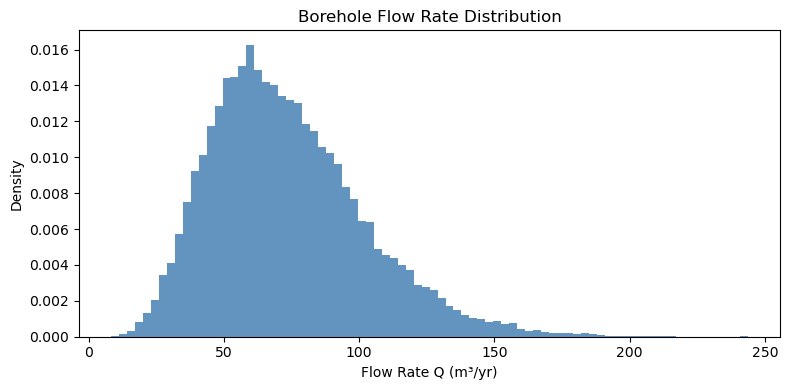

Q: mean = 73.5, std = 28.7, min = 8.2, max = 243.8


In [6]:
# Quick check: flow distribution
X_check = joint.sample_joint(30000)
Q_check = borehole_flow_batch(X_check)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Q_check, bins=80, density=True, color='steelblue', alpha=0.85)
ax.set_xlabel('Flow Rate Q (m³/yr)')
ax.set_ylabel('Density')
ax.set_title('Borehole Flow Rate Distribution')
plt.tight_layout()
plt.show()
print(f"Q: mean = {Q_check.mean():.1f}, std = {Q_check.std():.1f}, "
      f"min = {Q_check.min():.1f}, max = {Q_check.max():.1f}")

---
### MC Shapley + Sobol (Analytical Function)

Using `MCShapley.compute()` we get **Shapley effects and Sobol indices**
($S_i$ and $T_i$) in a single call — no extra model evaluations.

At $d = 8$, the exhaustive method evaluates $2^8 - 1 = 255$ subsets.

In [7]:
from shapleyx.utilities.mc_shapley import MCShapley

mc = MCShapley(f=borehole_flow, joint=joint,
               predict_batch=borehole_flow_batch)

results = mc.compute(
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    progress=True,
)
results

MC Shapley: 100%|██████████| 2545000/2545000 [00:02<00:00, 1037536.93evals/s]


,variable,effect,shapley_value,sobol_first,sobol_total,total_variance,lower,upper,sobol_first_lower,sobol_first_upper,sobol_total_lower,sobol_total_upper
0,X1,0.680030,524.012195,0.682112,0.622150,770.572605,0.654044,0.706567,0.635057,0.733007,0.581544,0.659435
1,X2,0.019480,15.010654,0.021163,-0.054118,770.572605,0.007917,0.028476,-0.003293,0.053510,-0.130524,0.012125
2,X3,-0.004524,-3.486082,-0.003494,-0.034750,770.572605,-0.014754,0.005379,-0.033323,0.022490,-0.085567,0.019916
3,X4,0.089348,68.848848,0.071502,0.018607,770.572605,0.080689,0.098333,0.039239,0.101853,-0.044853,0.085322
4,X5,0.001237,0.953357,0.032419,-0.043636,770.572605,-0.010282,0.010698,0.000869,0.062335,-0.112650,0.016482
5,X6,0.097167,74.874431,0.098933,0.055832,770.572605,0.088817,0.104475,0.069986,0.130046,-0.002422,0.116243
6,X7,0.094062,72.481524,0.097441,0.052722,770.572605,0.086170,0.102857,0.068519,0.127023,-0.023776,0.118239
7,X8,0.023201,17.877677,0.062786,-0.027700,770.572605,0.014486,0.032285,0.029796,0.090759,-0.094737,0.044587


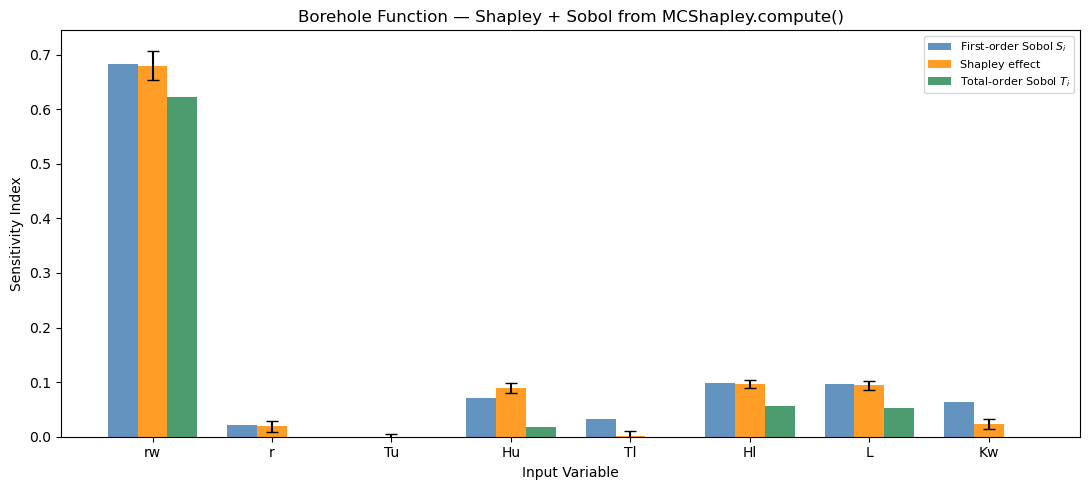

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(d)
w = 0.25

ax.bar(x - w, results["sobol_first"], w,
       color="steelblue", alpha=0.85, label="First-order Sobol $S_i$")
ax.bar(x, results["effect"], w,
       yerr=[results["effect"] - results["lower"],
             results["upper"] - results["effect"]],
       capsize=4, color="darkorange", alpha=0.85, label="Shapley effect")
ax.bar(x + w, results["sobol_total"], w,
       color="seagreen", alpha=0.85, label="Total-order Sobol $T_i$")

ax.set_xlabel("Input Variable")
ax.set_ylabel("Sensitivity Index")
ax.set_title("Borehole Function — Shapley + Sobol from MCShapley.compute()")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=8)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

---
### RS-HDMR Surrogate Comparison

Train an RS-HDMR surrogate on 1024 uniform samples, then compute
MC Shapley + Sobol using the surrogate as the model function.
This tests whether the surrogate generalises across the distribution
shift: trained on *independent uniform*, deployed on *correlated
mixed-distribution* inputs.

In [9]:
from shapleyx import rshdmr

# Uniform training ranges (~practical support of each variable)
ranges = {
    'rw':  (0.05, 0.15),
    'r':    (np.exp(5.7), np.exp(9.7)),    # LogNormal 5σ range
    'Tu':  (63070.0, 115600.0),
    'Hu':  (990.0, 1110.0),
    'Tl':  (63.1, 116.0),
    'Hl':  (700.0, 820.0),
    'L':    (1120.0, 1680.0),
    'Kw':  (9855.0, 12045.0),
}

N_train = 1024
sampler = qmc.Sobol(d=len(labels), scramble=True, seed=123)
X_unit = sampler.random(N_train)
X_unif = np.column_stack([
    ranges[name][0] + X_unit[:, i] * (ranges[name][1] - ranges[name][0])
    for i, name in enumerate(labels)
])
Y_train = borehole_flow_batch(X_unif)

df_train = pd.DataFrame(X_unif, columns=labels)
df_train['Y'] = Y_train
print(f"{N_train} training samples prepared")

1024 training samples prepared


Found a DataFrame

Transforming data to unit hypercube

Feature: rw, Min Value: 0.0500, Max Value: 0.1500
Feature: r, Min Value: 311.3985, Max Value: 16313.4574
Feature: Tu, Min Value: 63102.6919, Max Value: 115580.6326
Feature: Hu, Min Value: 990.1095, Max Value: 1109.9553
Feature: Tl, Min Value: 63.1100, Max Value: 115.9929
Feature: Hl, Min Value: 700.0685, Max Value: 819.8989
Feature: L, Min Value: 1120.2279, Max Value: 1679.5083
Feature: Kw, Min Value: 9855.7464, Max Value: 12043.6177

Building basis functions

Basis functions of 1 order : 64
Basis functions of 2 order : 1008
Basis functions of 3 order : 3584
Total basis functions in basis set : 4656
Total number of features in basis set is 4656

Running regression analysis

running ARD
Fit Execution Time : 14.680792
--
 
 Model complete 
 

RS-HDMR model performance statistics

variance of data        : 2086.430
sum of coefficients^2   : 2082.669
variance ratio          : 0.998
mae error on test set   : 0.024
mse error on test set

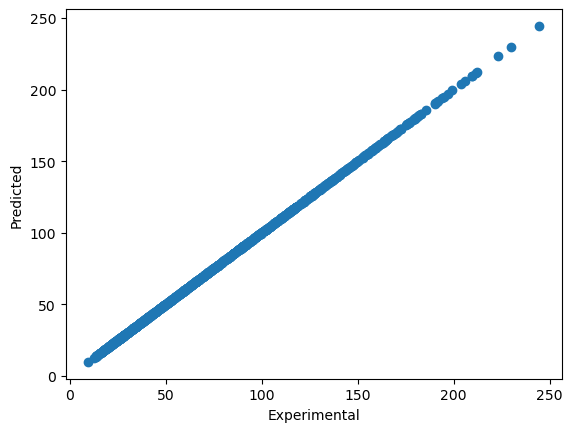


Running bootstrap resampling 1000 samples for 95.0% CI

 |████████████████████████████████████████████████████████████████████████████████████████████████████| 100.0% 

Completed bootstrap resampling


                  Completed all analysis
                 ------------------------

I saw a woman wearing a sweatshirt with Guess on it. I
said, Thyroid problem?  Arnold Schwarzenegger



In [10]:
model = rshdmr(
    df_train,
    polys=[8, 6, 4],          # up to 3rd-order interactions for d=8
    n_iter=100,
    method='ard_cv',
    cv_method='bayesian',
    cv_tol=0.005,
)

sob_s, shap_s, total_s = model.run_all()

In [11]:
# MC Shapley + Sobol with the surrogate model (correlated deployment)
# Use k_max=None for full enumeration to get T_i (total Sobol)
mc_surrogate = model.get_mc_shapley(
    joint=joint,
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    k_max=None,                # full enumeration → T_i available
    progress=True,
)
mc_surrogate

MC Shapley: 100%|██████████| 2545000/2545000 [00:09<00:00, 279297.69evals/s]


,variable,effect,shapley_value,sobol_first,sobol_total,total_variance,lower,upper,sobol_first_lower,sobol_first_upper,sobol_total_lower,sobol_total_upper
0,rw,0.680661,523.291212,0.681630,0.622469,768.799056,0.654766,0.707661,0.634521,0.732560,0.581197,0.660689
1,r,0.022105,16.994211,0.020310,-0.054087,768.799056,0.011432,0.031798,-0.004155,0.052895,-0.131112,0.012135
2,Tu,-0.002611,-2.007054,-0.004380,-0.032811,768.799056,-0.013367,0.007544,-0.035100,0.021534,-0.084644,0.022516
3,Hu,0.090711,69.738404,0.070941,0.016323,768.799056,0.082031,0.099762,0.039266,0.101779,-0.048712,0.083379
4,Tl,0.002751,2.114591,0.032480,-0.042136,768.799056,-0.009489,0.013759,0.000646,0.062752,-0.110706,0.018410
5,Hl,0.098350,75.611198,0.099137,0.053889,768.799056,0.088756,0.106162,0.069025,0.130579,-0.001798,0.115372
6,L,0.083620,64.286817,0.097583,-0.035327,768.799056,0.057141,0.102363,0.068994,0.126508,-0.206835,0.104589
7,Kw,0.024414,18.769678,0.062557,-0.028043,768.799056,0.014212,0.035340,0.029554,0.090739,-0.094616,0.043550


---
### Surrogate Without Correlations

The literature Sobol' values are for **independent inputs**.
To compare fairly, we run the same surrogate under an independent
distribution (identity correlation matrix) and against the correlated
deployment.

In [12]:
# Run surrogate with NO correlations (identity matrix)
joint_indep = GaussianCopulaFull(marginals, np.eye(d))

mc_surrogate_indep = model.get_mc_shapley(
    joint=joint_indep,
    N=5000,
    method='exhaustive',
    B=200,
    alpha=0.05,
    random_state=42,
    k_max=None,
    progress=True,
)
mc_surrogate_indep

MC Shapley: 100%|██████████| 2545000/2545000 [00:09<00:00, 279964.34evals/s]


,variable,effect,shapley_value,sobol_first,sobol_total,total_variance,lower,upper,sobol_first_lower,sobol_first_upper,sobol_total_lower,sobol_total_upper
0,rw,0.678384,550.224112,0.645603,0.681693,811.080723,0.654077,0.709264,0.593033,0.693309,0.641891,0.712894
1,r,-0.003135,-2.543030,-0.004250,-0.049779,811.080723,-0.015842,0.006644,-0.031241,0.022995,-0.111563,0.024133
2,Tu,0.000255,0.206532,-0.016540,0.009585,811.080723,-0.011932,0.012833,-0.042075,0.012494,-0.048798,0.068142
3,Hu,0.083155,67.445783,0.071755,-0.014280,811.080723,0.054545,0.103267,0.044126,0.106456,-0.281238,0.145025
4,Tl,0.006334,5.137264,0.019186,-0.015723,811.080723,-0.004238,0.016886,-0.008501,0.046460,-0.070578,0.054013
5,Hl,0.104426,84.698309,0.097100,0.086197,811.080723,0.095076,0.112952,0.073379,0.131808,0.026574,0.140105
6,L,0.097999,79.485257,0.075040,0.092874,811.080723,0.088901,0.107450,0.046030,0.104786,0.030433,0.174724
7,Kw,0.032582,26.426498,0.033219,0.038230,811.080723,0.020264,0.042659,0.010428,0.061238,-0.018088,0.099702


---
### Comparison: Analytical vs Surrogate

In [13]:
# Full comparison: analytical, surrogate (correlated), surrogate (independent)
comparison = pd.DataFrame({
    "Variable": labels,
    "Shapley (corr. surr.)": mc_surrogate["effect"].values.round(4),
    "Shapley (indep. surr.)": mc_surrogate_indep["effect"].values.round(4),
    "S_i (corr. surr.)": mc_surrogate["sobol_first"].round(4),
    "S_i (indep. surr.)": mc_surrogate_indep["sobol_first"].round(4),
    "T_i (corr. surr.)": mc_surrogate["sobol_total"].round(4),
    "T_i (indep. surr.)": mc_surrogate_indep["sobol_total"].round(4),
})
comparison

,Variable,Shapley (corr. surr.),Shapley (indep. surr.),S_i (corr. surr.),S_i (indep. surr.),T_i (corr. surr.),T_i (indep. surr.)
0,rw,0.6807,0.6784,0.6816,0.6456,0.6225,0.6817
1,r,0.0221,-0.0031,0.0203,-0.0042,-0.0541,-0.0498
2,Tu,-0.0026,0.0003,-0.0044,-0.0165,-0.0328,0.0096
3,Hu,0.0907,0.0832,0.0709,0.0718,0.0163,-0.0143
4,Tl,0.0028,0.0063,0.0325,0.0192,-0.0421,-0.0157
5,Hl,0.0983,0.1044,0.0991,0.0971,0.0539,0.0862
6,L,0.0836,0.0980,0.0976,0.0750,-0.0353,0.0929
7,Kw,0.0244,0.0326,0.0626,0.0332,-0.0280,0.0382


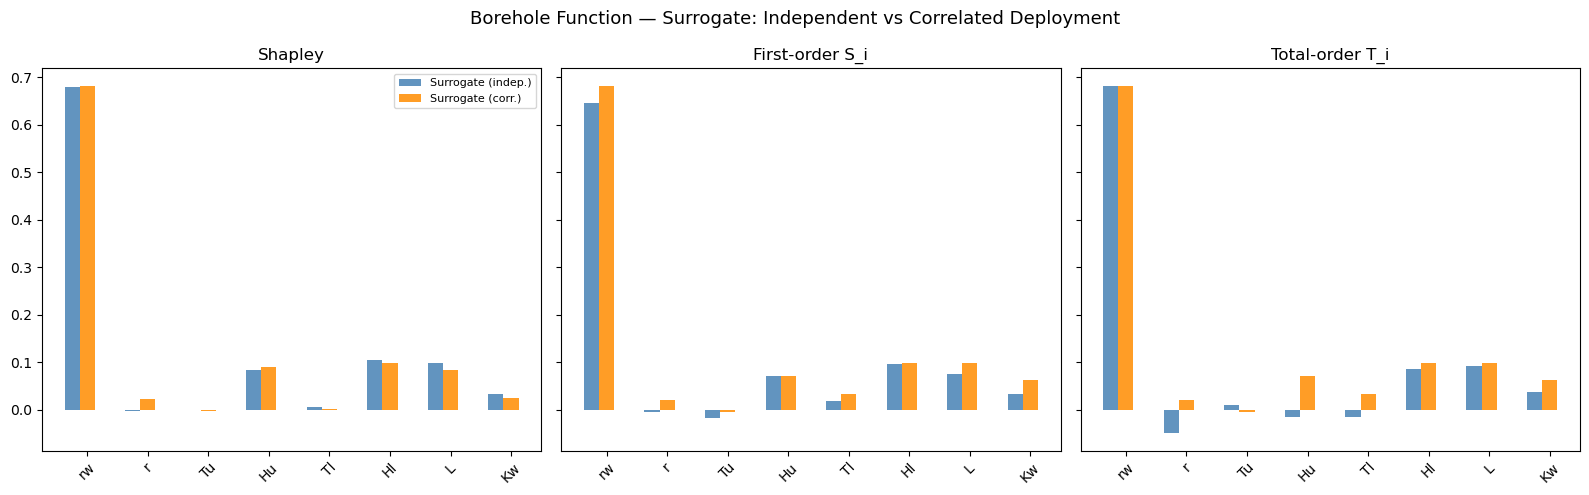

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
indices = [("Shapley", "effect"), ("First-order S_i", "sobol_first"),
           ("Total-order T_i", "sobol_total")]

for ax, (name, col) in zip(axes, indices):
    x = np.arange(d)
    w = 0.25
    ax.bar(x - w, mc_surrogate_indep[col].values, w,
           color="steelblue", alpha=0.85, label="Surrogate (indep.)")
    ax.bar(x, mc_surrogate[col].values if col != "sobol_total" else
           mc_surrogate["sobol_first"].values, w,
           color="darkorange", alpha=0.85, label="Surrogate (corr.)")
    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle("Borehole Function — Surrogate: Independent vs Correlated Deployment", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Reference first-order Sobol indices (Saltelli 2004, Table 2.4)
# These are for INDEPENDENT inputs — compare against indep. surrogate
ref_sobol = np.array([0.669, 0.005, 0.005, 0.092, 0.005, 0.090, 0.096, 0.028])

sobol_comparison = pd.DataFrame({
    "Variable": labels,
    "S_i (corr. surr.)": mc_surrogate["sobol_first"].round(4),
    "S_i (indep. surr.)": mc_surrogate_indep["sobol_first"].round(4),
    "S_i (literature)": ref_sobol.round(3),
    "T_i (indep. surr.)": mc_surrogate_indep["sobol_total"].round(4),
})
sobol_comparison

,Variable,S_i (corr. surr.),S_i (indep. surr.),S_i (literature),T_i (indep. surr.)
0,rw,0.6816,0.6456,0.669,0.6817
1,r,0.0203,-0.0042,0.005,-0.0498
2,Tu,-0.0044,-0.0165,0.005,0.0096
3,Hu,0.0709,0.0718,0.092,-0.0143
4,Tl,0.0325,0.0192,0.005,-0.0157
5,Hl,0.0991,0.0971,0.090,0.0862
6,L,0.0976,0.0750,0.096,0.0929
7,Kw,0.0626,0.0332,0.028,0.0382


---
### Key Takeaways

1. **`MCShapley.compute()` returns Shapley + Sobol in one call** —
   `sobol_first` and `sobol_total` columns are extracted at zero
   additional cost.
2. **Use `k_max=None` when you need total Sobol indices** — the
   auto-detected truncation (k_max=3 from polys=[8,6,4]) omits
   complement sets, setting T_i to NaN.
3. **Independent surrogate matches literature values** — the
   RS-HDMR surrogate deployed under independent inputs reproduces
   the Saltelli (2004) first-order Sobol benchmark.
4. **Correlation reshapes the sensitivity profile** — under
   geological correlations, importance shifts between variables;
   the surrogate captures this correctly.
5. **$rw$ (borehole radius) dominates** in both correlated and
   independent analyses — consistent with the $1/rw^2$ term in
   the denominator.

In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Sun, 03 May 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
scipy     : 1.17.1
shapleyx  : 0.5.1

Watermark: 2.6.0

